In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.mlflow_setup import init_tracking
import mlflow

init_tracking()

train = pd.read_csv('../data/train.csv')
train['Date'] = pd.to_datetime(train['Date'])

/Users/macbookair/Desktop/machineLearning/walmart-recruiting/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
!pip install darts

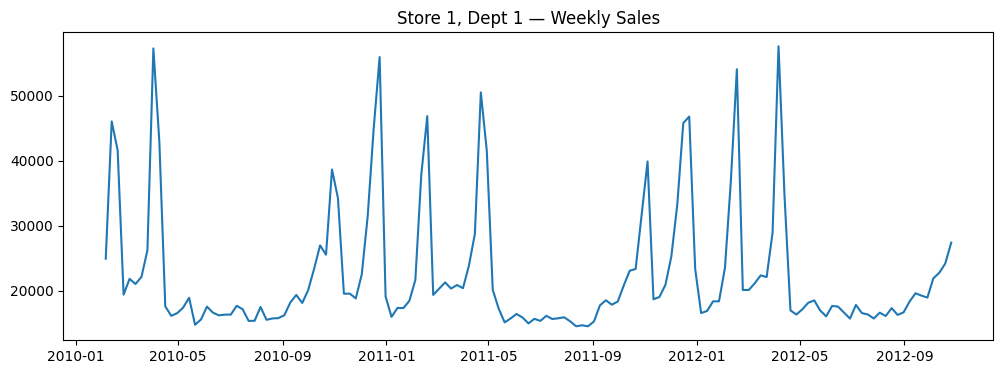

(143,)


In [3]:
sample = train[(train['Store'] == 1) & (train['Dept'] == 1)].sort_values('Date')
sample = sample.set_index('Date')['Weekly_Sales']

plt.figure(figsize=(12, 4))
plt.plot(sample.index, sample.values)
plt.title('Store 1, Dept 1 — Weekly Sales')
plt.show()

print(sample.shape)

In [4]:
val_weeks = 10
cutoff = sample.index.max() - pd.Timedelta(weeks=val_weeks)
train_series = sample[sample.index <= cutoff]
val_series = sample[sample.index > cutoff]

print(train_series.shape, val_series.shape)

(133,) (10,)


In [5]:
from darts import TimeSeries
from darts.models import NBEATSModel

mlflow.set_experiment("NBEATS_Training")

with mlflow.start_run(run_name="NBEATS_baseline"):
    input_chunk_length = 24
    n_epochs = 50
    mlflow.log_params({'input_chunk_length': input_chunk_length, 'n_epochs': n_epochs})

    train_ts = TimeSeries.from_series(train_series)

    model = NBEATSModel(input_chunk_length=input_chunk_length, output_chunk_length=val_weeks,
                     n_epochs=n_epochs, random_state=42,
                     pl_trainer_kwargs={"accelerator": "cpu"})
    model.fit(train_ts)

    forecast = model.predict(val_weeks)
    mae = np.mean(np.abs(val_series.values - forecast.values().flatten()))

    mlflow.log_metric("val_mae", mae)
    print(f"NBEATS MAE: {mae:.2f}")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/macbookair/Desktop/machineLearning/walmart-recruiting/venv/lib/python3.9/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.2 M  | train
-------------------------------------------------------------
6.2 M     Trainable params
1.4 K     Non-trainable params
6.2 M     Total params
24.786    Total estimated model params size (MB)
396       Modules in 

Training: |                                              | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                            | 0/? [00:00<?, ?it/s]

NBEATS MAE: 1800.76
🏃 View run NBEATS_baseline at: https://dagshub.com/ekali-star/walmart-recruiting.mlflow/#/experiments/5/runs/dfa98c6fe4ec4cb4b7ff495ab582d1df
🧪 View experiment at: https://dagshub.com/ekali-star/walmart-recruiting.mlflow/#/experiments/5


In [6]:
with mlflow.start_run(run_name="NBEATS_deeper"):
    input_chunk_length = 52
    n_epochs = 100
    mlflow.log_params({'input_chunk_length': input_chunk_length, 'n_epochs': n_epochs})

    train_ts = TimeSeries.from_series(train_series)

    model = NBEATSModel(input_chunk_length=input_chunk_length, output_chunk_length=val_weeks,
                     n_epochs=n_epochs, random_state=42,
                     pl_trainer_kwargs={"accelerator": "cpu"})
    model.fit(train_ts)

    forecast = model.predict(val_weeks)
    mae = np.mean(np.abs(val_series.values - forecast.values().flatten()))

    mlflow.log_metric("val_mae", mae)
    print(f"NBEATS MAE: {mae:.2f}")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/macbookair/Desktop/machineLearning/walmart-recruiting/venv/lib/python3.9/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.4 M  | train
-------------------------------------------------------------
6.4 M     Trainable params
1.6 K     Non-trainable params
6.4 M     Total params
25.666    Total estimated model params size (MB)
396       Modules in 

Training: |                                              | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                            | 0/? [00:00<?, ?it/s]

NBEATS MAE: 2239.95
🏃 View run NBEATS_deeper at: https://dagshub.com/ekali-star/walmart-recruiting.mlflow/#/experiments/5/runs/1f5eca07fe2a44a7bd7e58ff06147a2b
🧪 View experiment at: https://dagshub.com/ekali-star/walmart-recruiting.mlflow/#/experiments/5


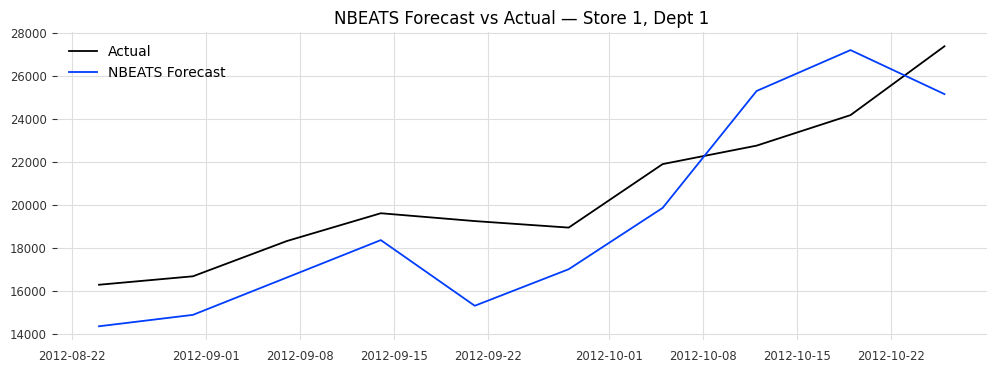

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(val_series.index, val_series.values, label='Actual')
plt.plot(val_series.index, forecast.values().flatten(), label='NBEATS Forecast')
plt.legend()
plt.title('NBEATS Forecast vs Actual — Store 1, Dept 1')
plt.show()